In [13]:
import pandas as pd
import numpy as np

In [5]:
df_old = pd.read_csv("results/data/jaxqsofit_mar12j.csv")
df_new = pd.read_csv("results/data/jaxqsofit_mar15c.csv")


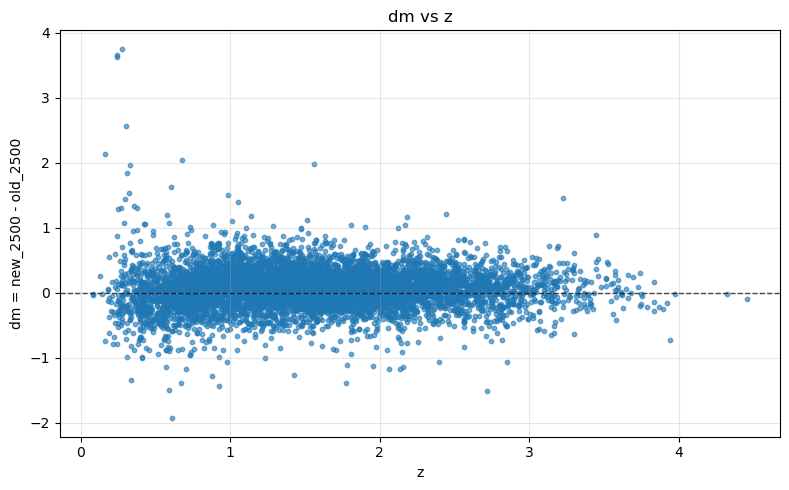

In [ ]:
# dm = new - old, then plot vs z
dm_z = (
    cmp.merge(df_new[["object_id", "redshift"]], on="object_id", how="left")
       .merge(df_old[["object_id", "z"]], on="object_id", how="left")
)



dm_z["z_plot"] = dm_z["redshift"].fillna(dm_z["z"])
dm_z["dm"] = dm_z["new_2500"] - dm_z["old_2500"]
dm_z = dm_z.dropna(subset=["z_plot", "dm"]).copy()
dm_z = dm_z[(dm_z["old_2500"] > -100) & (dm_z["new_2500"] > -100)].sort_values("z_plot")

rolling_median = (
    dm_z[["z_plot", "dm"]]
    .rolling(window=200, center=True, min_periods=50)
    .median()
    .dropna()
)
dm_z = dm_z.dropna(subset=["z_plot", "dm"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dm_z["z_plot"], dm_z["dm"], s=10, alpha=0.6)
ax.axhline(0, color="k", lw=1, ls="--", alpha=0.7)

ax.set_xlabel("z")
ax.set_ylabel("dm = new_2500 - old_2500")
ax.set_title("dm vs z")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

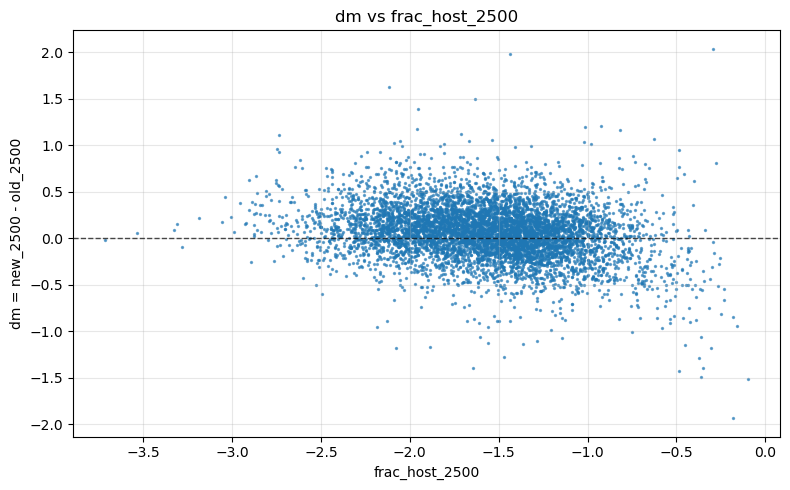

In [15]:
# dm = new_2500 - old_2500 vs frac_host_2500
dm_host = cmp.merge(
    df_old[["object_id", "frac_host_2500"]],
    on="object_id",
    how="left",
)

dm_host["dm"] = dm_host["new_2500"] - dm_host["old_2500"]
dm_host = dm_host.dropna(subset=["dm", "frac_host_2500"])

# keep physical host fractions, remove sentinels
dm_host = dm_host[(dm_host["frac_host_2500"] >= 0) & (dm_host["frac_host_2500"] <= 1)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(np.log10(dm_host["frac_host_2500"]), dm_host["dm"], s=2, alpha=0.6)
ax.axhline(0, color="k", lw=1, ls="--", alpha=0.7)

ax.set_xlabel("frac_host_2500")
ax.set_ylabel("dm = new_2500 - old_2500")
ax.set_title("dm vs frac_host_2500")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

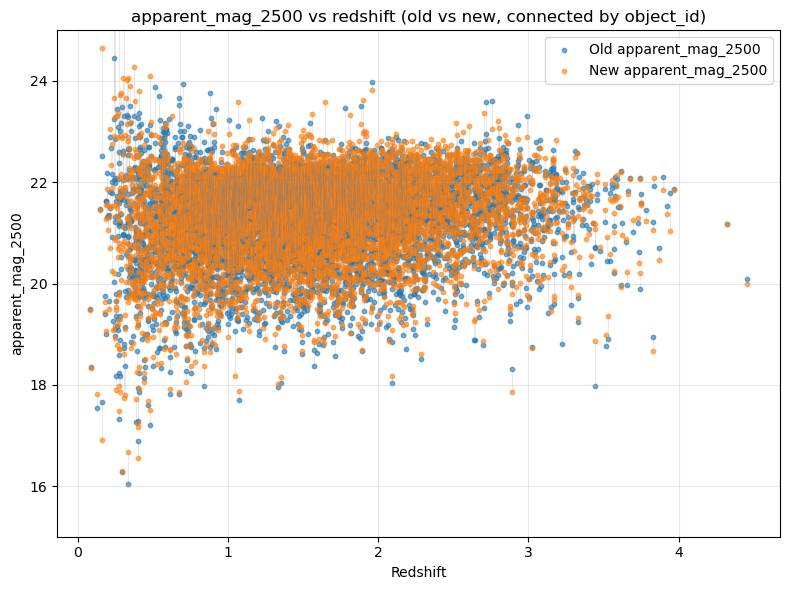

In [16]:
# Merge old/new apparent_mag_2500 and keep one redshift column
cmp_z = (
    df_old[["object_id", "apparent_mag_2500", "z"]]
    .rename(columns={"apparent_mag_2500": "old_2500", "z": "z_old"})
    .merge(
        df_new[["object_id", "apparent_mag_2500", "redshift"]].rename(
            columns={"apparent_mag_2500": "new_2500"}
        ),
        on="object_id",
        how="inner",
    )
)

cmp_z["z_plot"] = cmp_z["redshift"].fillna(cmp_z["z_old"])

# Remove NaNs and obvious sentinel values (e.g., -1e9)
cmp_z = cmp_z.dropna(subset=["z_plot", "old_2500", "new_2500"])
cmp_z = cmp_z[(cmp_z["old_2500"] > -100) & (cmp_z["new_2500"] > -100)]

fig, ax = plt.subplots(figsize=(8, 6))

# Connect old -> new for each object_id at the same redshift
ax.vlines(
    cmp_z["z_plot"],
    cmp_z["old_2500"],
    cmp_z["new_2500"],
    color="gray",
    alpha=0.2,
    linewidth=0.6,
)

# Old and new points
ax.scatter(cmp_z["z_plot"], cmp_z["old_2500"], s=10, alpha=0.6, label="Old apparent_mag_2500")
ax.scatter(cmp_z["z_plot"], cmp_z["new_2500"], s=10, alpha=0.6, label="New apparent_mag_2500")

ax.set_xlabel("Redshift")
ax.set_ylabel("apparent_mag_2500")
ax.set_title("apparent_mag_2500 vs redshift (old vs new, connected by object_id)")
ax.invert_yaxis()  # magnitudes: smaller = brighter
ax.set_ylim(15, 25)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

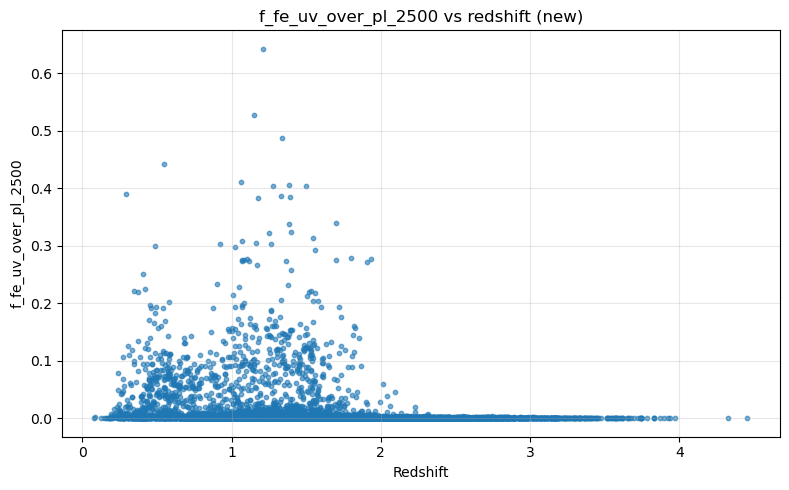

In [6]:
# Plot host fraction at 2500A vs redshift for the new catalog
ycol = "f_fe_uv_over_pl_2500"

plot_df = df_new[["redshift", ycol]].dropna().copy()
#plot_df = plot_df[(plot_df[ycol] >= 0) & (plot_df[ycol] <= 1)]  # remove sentinel/unphysical values

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["redshift"], plot_df[ycol], s=10, alpha=0.6)

ax.set_xlabel("Redshift")
ax.set_ylabel(ycol)
ax.set_title(f"{ycol} vs redshift (new)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [7]:
len(df_new)

7239

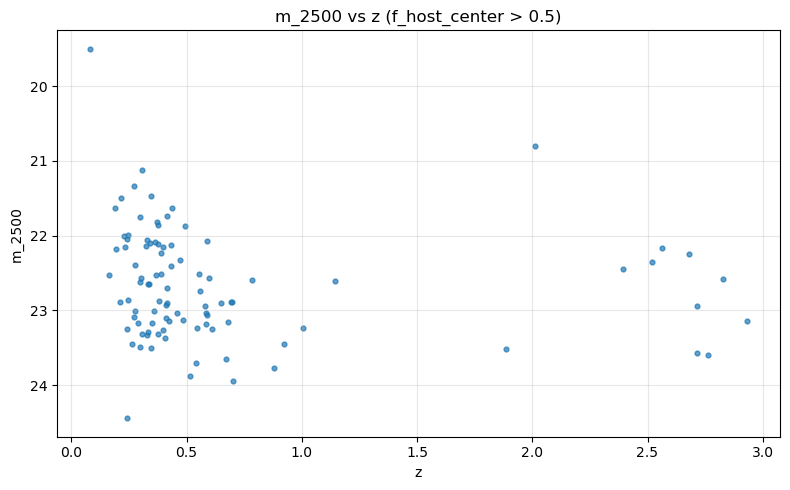

In [8]:
plot_df = df_new[["z", "apparent_mag_2500", "f_host_center"]].dropna().copy()
plot_df = plot_df[(plot_df["f_host_center"] > 0.5)]#& (plot_df["apparent_mag_2500"] > -100)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["z"], plot_df["apparent_mag_2500"], s=12, alpha=0.7)

ax.set_xlabel("z")
ax.set_ylabel("m_2500")
ax.set_title("m_2500 vs z (f_host_center > 0.5)")
ax.invert_yaxis()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

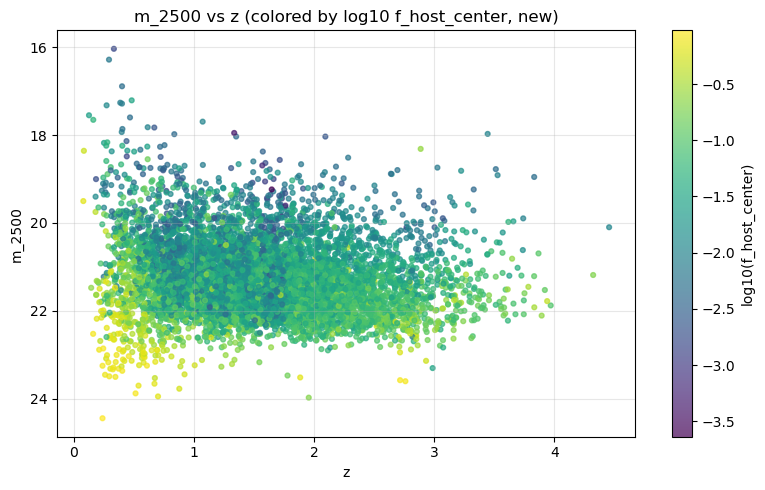

In [9]:
import numpy as np

tmp = df_new[["z", "apparent_mag_2500", "f_host_center"]].dropna().copy()
#tmp = tmp[(tmp["apparent_mag_2500"] > -100) & (tmp["f_host_center"] > 0)]
tmp["log_f_host_new"] = np.log10(tmp["f_host_center"])

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    tmp["z"],
    tmp["apparent_mag_2500"],
    c=tmp["log_f_host_new"],
    s=12,
    alpha=0.7,
    cmap="viridis",
)

ax.set_xlabel("z")
ax.set_ylabel("m_2500")
ax.set_title("m_2500 vs z (colored by log10 f_host_center, new)")
ax.invert_yaxis()
ax.grid(alpha=0.3)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("log10(f_host_center)")

fig.tight_layout()
plt.show()

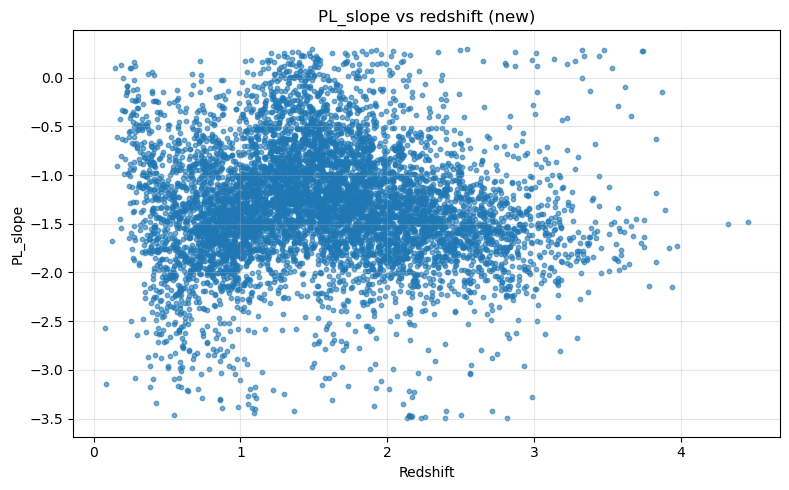

In [10]:
plot_df = df_new[["redshift", "PL_slope"]].dropna().copy()
plot_df = plot_df[(plot_df["PL_slope"] > -100) & (plot_df["PL_slope"] < 100)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["redshift"], plot_df["PL_slope"], s=10, alpha=0.6)

ax.set_xlabel("Redshift")
ax.set_ylabel("PL_slope")
ax.set_title("PL_slope vs redshift (new)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

def plot_m2500_vs_z_colorpanels(
    df,
    color_cols=("f_host_center", "f_fe_uv_over_pl_2500", "f_bc_over_pl_3000"),
    xcol="z",
    ycol="apparent_mag_2500",
    cuts=None,
    log_color=True,
    color_clip=None,   # dict: {col: (vmin, vmax)} in displayed space (log space if log_color=True)
    cmap="viridis",
    figsize=(11, 12),
    s=12,
    alpha=0.7,
    thin=1,
):
    cols = [xcol, ycol] + list(color_cols)
    base = df[cols].copy().dropna(subset=[xcol, ycol])
    cuts = {} if cuts is None else cuts
    color_clip = {} if color_clip is None else color_clip

    # Pretty colorbar labels
    label_map = {
        "f_host_center": r"f_{\mathrm{host}}",
        "f_fe_uv_over_pl_2500": r"f_{\mathrm{Fe\, II}}",
        "f_bc_over_pl_3000": r"f_{\mathrm{BC}}",
    }

    fig, axes = plt.subplots(len(color_cols), 1, figsize=figsize, sharex=True, sharey=True)
    if len(color_cols) == 1:
        axes = [axes]

    for ax, ccol in zip(axes, color_cols):
        d = base.dropna(subset=[ccol]).copy()
        if thin and thin > 1:
            d = d.iloc[::thin].copy()

        if log_color:
            d = d[d[ccol] > 0].copy()
            c_all = np.log10(d[ccol].to_numpy(dtype=float))
        else:
            c_all = d[ccol].to_numpy(dtype=float)

        keep = np.ones(len(d), dtype=bool)
        if ccol in cuts and cuts[ccol] is not None:
            lo, hi = cuts[ccol]
            if lo is not None:
                keep &= (d[ccol].to_numpy() >= lo)
            if hi is not None:
                keep &= (d[ccol].to_numpy() <= hi)

        d_keep, d_cut = d.iloc[keep], d.iloc[~keep]
        c_keep, c_cut = c_all[keep], c_all[~keep]

        # Per-panel clipping
        clip_lo, clip_hi = color_clip.get(ccol, (None, None))
        c_keep_plot = c_keep.copy()
        c_cut_plot = c_cut.copy()
        if clip_lo is not None:
            c_keep_plot = np.clip(c_keep_plot, clip_lo, None)
            c_cut_plot = np.clip(c_cut_plot, clip_lo, None)
        if clip_hi is not None:
            c_keep_plot = np.clip(c_keep_plot, None, clip_hi)
            c_cut_plot = np.clip(c_cut_plot, None, clip_hi)

        # Colorbar limits from clipped all-points (keep+cut)
        c_all_plot = c_all.copy()
        if clip_lo is not None:
            c_all_plot = np.clip(c_all_plot, clip_lo, None)
        if clip_hi is not None:
            c_all_plot = np.clip(c_all_plot, None, clip_hi)

        vmin = clip_lo if clip_lo is not None else np.nanmin(c_all_plot)
        vmax = clip_hi if clip_hi is not None else np.nanmax(c_all_plot)
        norm = colors.Normalize(vmin=vmin, vmax=vmax)

        ax.scatter(d_keep[xcol], d_keep[ycol], c=c_keep_plot, cmap=cmap, norm=norm, s=s, alpha=alpha, marker="o")
        ax.scatter(d_cut[xcol], d_cut[ycol], c=c_cut_plot, cmap=cmap, norm=norm, s=s*2.0, alpha=alpha, marker="x")

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax)

        base_label = label_map.get(ccol, ccol)
        cbar.set_label(rf"$\log_{{10}}({base_label})$" if log_color else base_label)

        ax.set_ylabel(r"$m_{2500\,\mathrm{\AA}}$")

    axes[-1].set_xlabel(xcol)
    axes[0].invert_yaxis()
    fig.tight_layout()
    return fig, axes


In [104]:
plt.style.use("style.mplstyle")

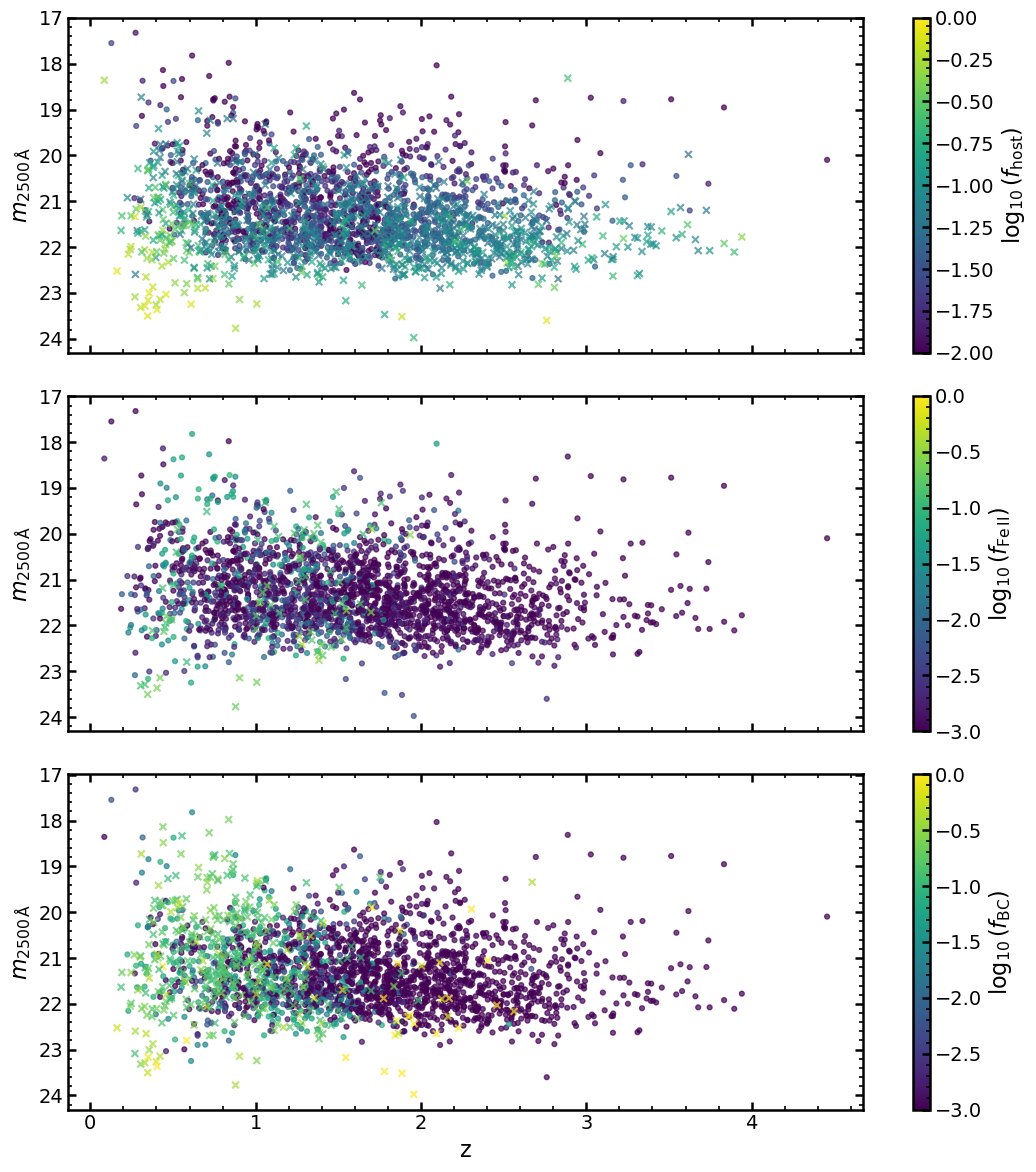

In [105]:
cuts = {
    "f_host_center": (0.0, 0.05),
    "f_fe_uv_over_pl_2500": (-np.inf, 0.1),
    "f_bc_over_pl_3000": (-np.inf, 0.1),
}

color_clip = {
    "f_host_center": (-2, 0.0),
    "f_fe_uv_over_pl_2500": (-3.0, 0.0),
    "f_bc_over_pl_3000": (-3.0, 0.0),
}
fig, axes = plot_m2500_vs_z_colorpanels(df_new, cuts=cuts, thin=3, color_clip=color_clip, log_color=True)
plt.show()

plt.show()
